In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("../data/processed/processed data.csv")

df.head()

,student_id,age,gender,major,GPA,course_load,avg_course_grade,attendance_rate,enrollment_status,lms_logins_past_month,avg_session_duration_minutes,assignment_submission_rate,forum_participation_count,video_completion_rate,risk_level
0,S1081,20.0,Male,Unknown,3.23,5,90.9,0.79,Graduated,32.0,76.0,0.87,0,0.70,Medium
1,S406,21.0,Male,Computer Science,2.97,4,63.9,0.97,Leave,28.0,49.0,0.76,16,0.73,Medium
2,S1495,23.0,Female,Arts,2.39,3,93.1,0.67,Graduated,7.0,77.0,0.82,5,0.93,High
3,S240,25.0,Female,Business,3.91,4,62.2,0.90,Graduated,32.0,80.0,0.63,6,0.87,Low
4,S611,22.0,Female,Engineering,3.89,3,71.0,0.82,Graduated,30.0,65.0,0.52,13,0.90,Medium


In [4]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (1475, 15)

Data types:
student_id                          str
age                             float64
gender                              str
major                               str
GPA                             float64
course_load                       int64
avg_course_grade                float64
attendance_rate                 float64
enrollment_status                   str
lms_logins_past_month           float64
avg_session_duration_minutes    float64
assignment_submission_rate      float64
forum_participation_count         int64
video_completion_rate           float64
risk_level                          str
dtype: object

Missing values:
student_id                      0
age                             0
gender                          0
major                           0
GPA                             0
course_load                     0
avg_course_grade                0
attendance_rate                 0
enrollment_status               0
lms_logins_past_month   

In [5]:
behaviour_cols = [
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

behaviour_df = df[behaviour_cols]

behaviour_df.describe()

,attendance_rate,lms_logins_past_month,avg_session_duration_minutes,assignment_submission_rate,forum_participation_count,video_completion_rate
count,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000
mean,0.795105,20.718644,51.861695,0.754034,9.662373,0.750569
std,0.122021,37.803213,55.455030,0.148443,5.779993,0.156352
min,-0.200000,-2.000000,1.000000,-0.200000,0.000000,-0.200000
25%,0.700000,10.000000,30.000000,0.630000,5.000000,0.620000
50%,0.790000,19.000000,49.000000,0.760000,10.000000,0.750000
75%,0.890000,28.000000,69.500000,0.870000,15.000000,0.880000
max,1.500000,1000.000000,1500.000000,1.500000,19.000000,1.500000


In [6]:
print(behaviour_df.describe().T)


                               count       mean        std  min    25%    50%  \
attendance_rate               1475.0   0.795105   0.122021 -0.2   0.70   0.79   
lms_logins_past_month         1475.0  20.718644  37.803213 -2.0  10.00  19.00   
avg_session_duration_minutes  1475.0  51.861695  55.455030  1.0  30.00  49.00   
assignment_submission_rate    1475.0   0.754034   0.148443 -0.2   0.63   0.76   
forum_participation_count     1475.0   9.662373   5.779993  0.0   5.00  10.00   
video_completion_rate         1475.0   0.750569   0.156352 -0.2   0.62   0.75   

                                75%     max  
attendance_rate                0.89     1.5  
lms_logins_past_month         28.00  1000.0  
avg_session_duration_minutes  69.50  1500.0  
assignment_submission_rate     0.87     1.5  
forum_participation_count     15.00    19.0  
video_completion_rate          0.88     1.5  


In [7]:
print("\nBehaviour feature ranges:")
for col in behaviour_cols:
    print(f"{col}: {df[col].min()} to {df[col].max()}")


Behaviour feature ranges:
attendance_rate: -0.2 to 1.5
lms_logins_past_month: -2.0 to 1000.0
avg_session_duration_minutes: 1.0 to 1500.0
assignment_submission_rate: -0.2 to 1.5
forum_participation_count: 0 to 19
video_completion_rate: -0.2 to 1.5


In [8]:
print(behaviour_df.describe().T)

                               count       mean        std  min    25%    50%  \
attendance_rate               1475.0   0.795105   0.122021 -0.2   0.70   0.79   
lms_logins_past_month         1475.0  20.718644  37.803213 -2.0  10.00  19.00   
avg_session_duration_minutes  1475.0  51.861695  55.455030  1.0  30.00  49.00   
assignment_submission_rate    1475.0   0.754034   0.148443 -0.2   0.63   0.76   
forum_participation_count     1475.0   9.662373   5.779993  0.0   5.00  10.00   
video_completion_rate         1475.0   0.750569   0.156352 -0.2   0.62   0.75   

                                75%     max  
attendance_rate                0.89     1.5  
lms_logins_past_month         28.00  1000.0  
avg_session_duration_minutes  69.50  1500.0  
assignment_submission_rate     0.87     1.5  
forum_participation_count     15.00    19.0  
video_completion_rate          0.88     1.5  


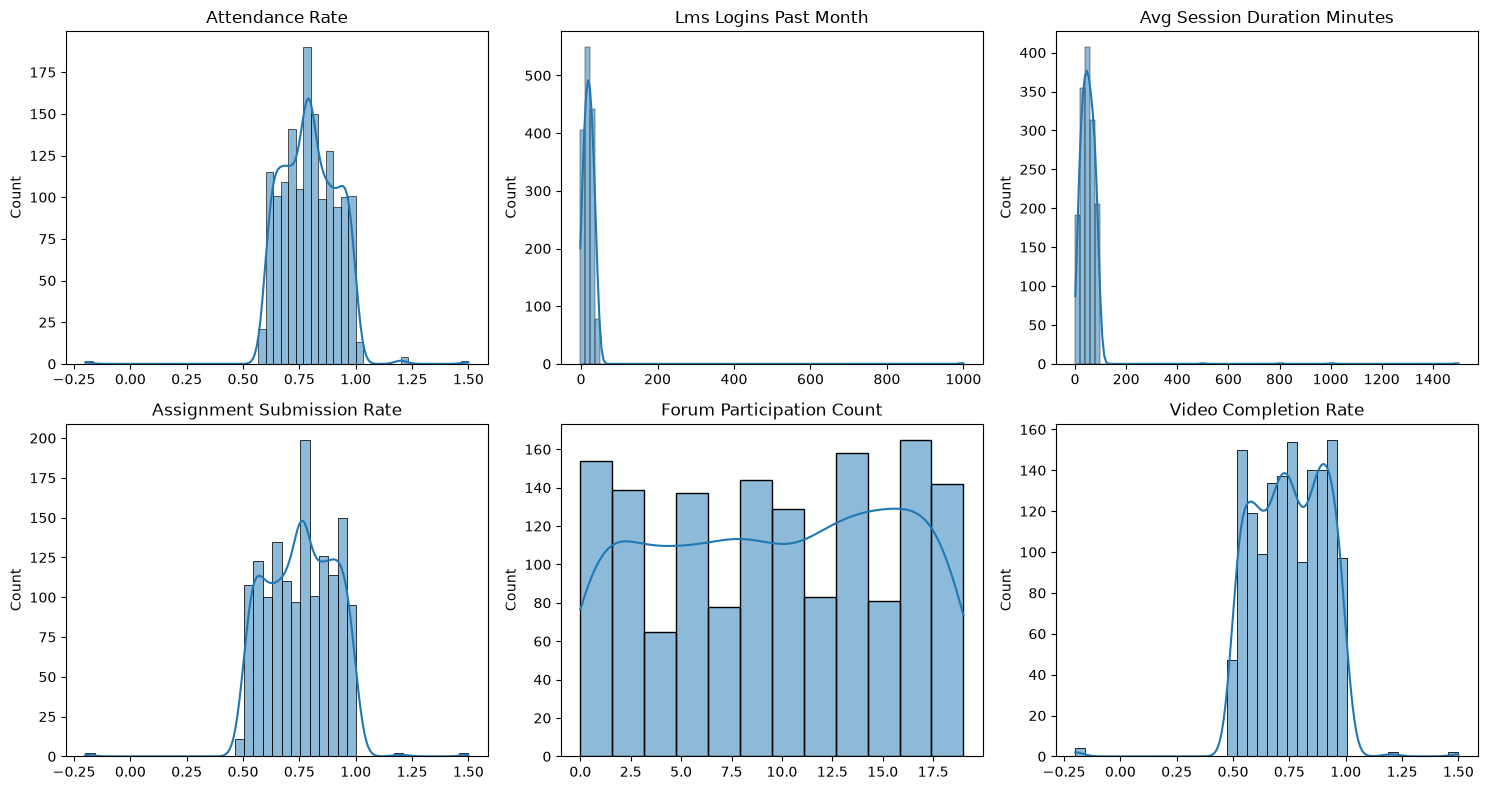

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), behaviour_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [10]:
risk_behaviour = df.groupby("risk_level")[behaviour_cols].mean()

risk_behaviour

,attendance_rate,lms_logins_past_month,avg_session_duration_minutes,assignment_submission_rate,forum_participation_count,video_completion_rate
risk_level,,,,,,
High,0.732135,19.287193,51.385511,0.758176,9.799483,0.749806
Low,0.915815,19.407407,55.855556,0.742667,9.637037,0.744407
Medium,0.832338,24.099537,50.217593,0.753727,9.432870,0.755787


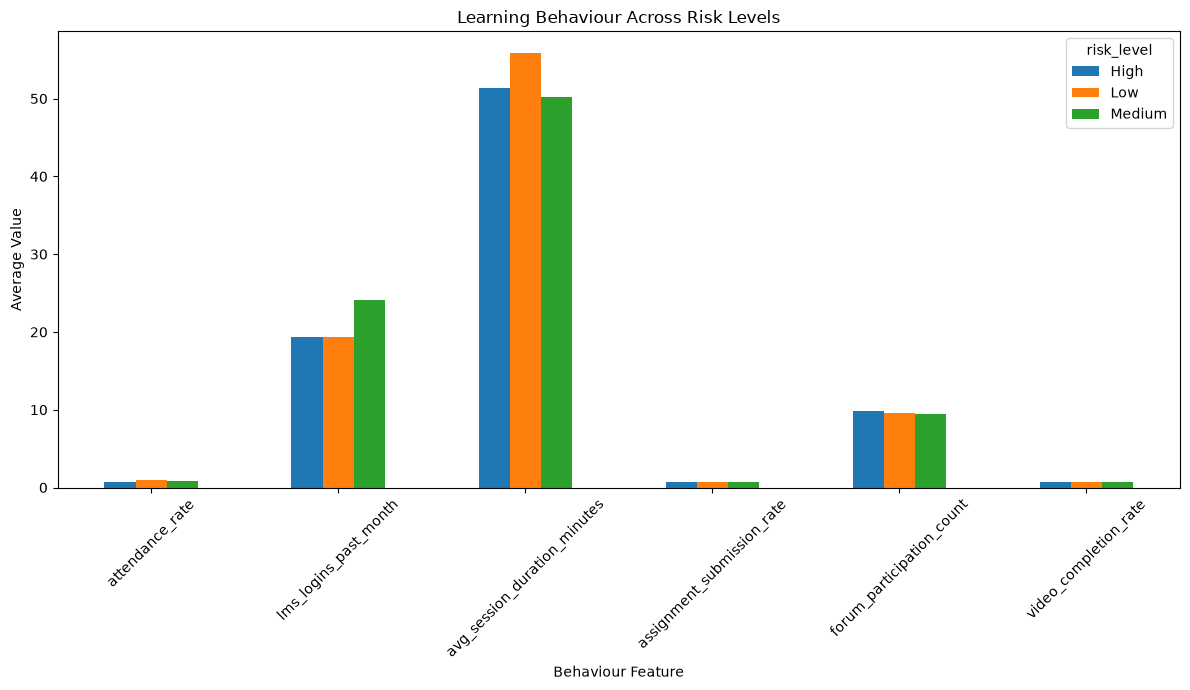

In [11]:
risk_behaviour.T.plot(kind="bar", figsize=(12, 7))

plt.title("Learning Behaviour Across Risk Levels")
plt.xlabel("Behaviour Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
risk_behaviour = df.groupby("risk_level")[behaviour_cols].mean()
risk_behaviour

,attendance_rate,lms_logins_past_month,avg_session_duration_minutes,assignment_submission_rate,forum_participation_count,video_completion_rate
risk_level,,,,,,
High,0.732135,19.287193,51.385511,0.758176,9.799483,0.749806
Low,0.915815,19.407407,55.855556,0.742667,9.637037,0.744407
Medium,0.832338,24.099537,50.217593,0.753727,9.432870,0.755787


In [13]:
risk_behaviour.round(3)

,attendance_rate,lms_logins_past_month,avg_session_duration_minutes,assignment_submission_rate,forum_participation_count,video_completion_rate
risk_level,,,,,,
High,0.732,19.287,51.386,0.758,9.799,0.750
Low,0.916,19.407,55.856,0.743,9.637,0.744
Medium,0.832,24.100,50.218,0.754,9.433,0.756


In [14]:
print(risk_behaviour.round(3).to_string())


            attendance_rate  lms_logins_past_month  avg_session_duration_minutes  assignment_submission_rate  forum_participation_count  video_completion_rate
risk_level                                                                                                                                                    
High                  0.732                 19.287                        51.386                       0.758                      9.799                  0.750
Low                   0.916                 19.407                        55.856                       0.743                      9.637                  0.744
Medium                0.832                 24.100                        50.218                       0.754                      9.433                  0.756


In [15]:
from scipy.stats import f_oneway

for col in behaviour_cols:
    high = df[df["risk_level"] == "High"][col]
    low = df[df["risk_level"] == "Low"][col]
    medium = df[df["risk_level"] == "Medium"][col]

    statistic, p_value = f_oneway(high, low, medium)

    print(f"{col}")
    print(f"F-statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.6f}")
    print()

attendance_rate
F-statistic: 389.7452
p-value: 0.000000

lms_logins_past_month
F-statistic: 2.4491
p-value: 0.086726

avg_session_duration_minutes
F-statistic: 0.9185
p-value: 0.399354

assignment_submission_rate
F-statistic: 1.0936
p-value: 0.335271

forum_participation_count
F-statistic: 0.5603
p-value: 0.571165

video_completion_rate
F-statistic: 0.4591
p-value: 0.631939



In [16]:
from scipy.stats import f_oneway

for col in behaviour_cols:
    groups = [
        df[df["risk_level"] == "High"][col],
        df[df["risk_level"] == "Medium"][col],
        df[df["risk_level"] == "Low"][col]
    ]

    f_stat, p_value = f_oneway(*groups)

    grand_mean = df[col].mean()
    ss_between = sum(len(group) * (group.mean() - grand_mean) ** 2 for group in groups)
    ss_total = ((df[col] - grand_mean) ** 2).sum()

    eta_squared = ss_between / ss_total

    print(f"{col}")
    print(f"Eta squared: {eta_squared:.4f}")
    print()

attendance_rate
Eta squared: 0.3462

lms_logins_past_month
Eta squared: 0.0033

avg_session_duration_minutes
Eta squared: 0.0012

assignment_submission_rate
Eta squared: 0.0015

forum_participation_count
Eta squared: 0.0008

video_completion_rate
Eta squared: 0.0006



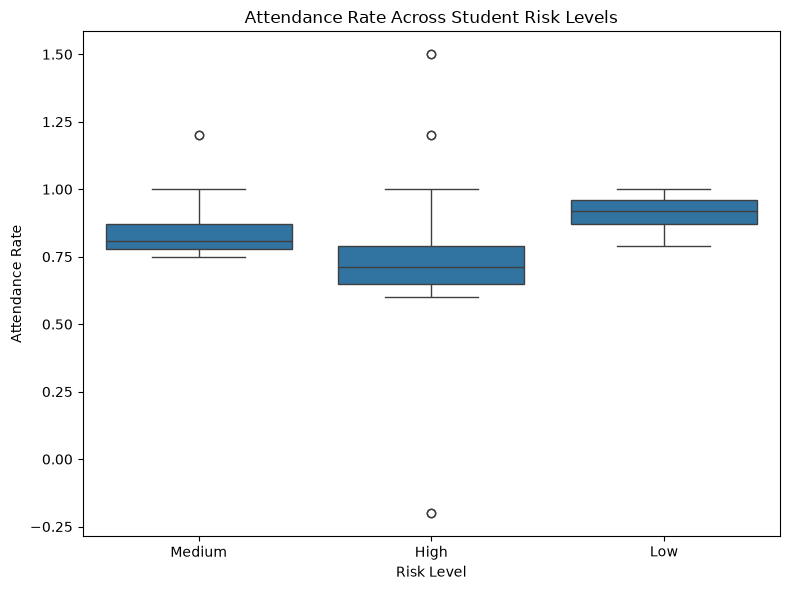

In [17]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="risk_level",
    y="attendance_rate"
)

plt.title("Attendance Rate Across Student Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Attendance Rate")

plt.tight_layout()
plt.show()

In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["attendance_rate"],
    groups=df["risk_level"],
    alpha=0.05
)

print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low   0.1837   0.0  0.1673  0.2001   True
  High Medium   0.1002   0.0  0.0863  0.1141   True
   Low Medium  -0.0835   0.0 -0.1014 -0.0655   True
---------------------------------------------------


In [19]:
numeric_cols = df.select_dtypes(include="number").columns

risk_numeric_means = df.groupby("risk_level")[numeric_cols].mean()

print(risk_numeric_means.round(3).to_string())

               age    GPA  course_load  avg_course_grade  attendance_rate  lms_logins_past_month  avg_session_duration_minutes  assignment_submission_rate  forum_participation_count  video_completion_rate
risk_level                                                                                                                                                                                                  
High        21.248  2.803        4.463            79.763            0.732                 19.287                        51.386                       0.758                      9.799                  0.750
Low         21.670  3.454        4.515            79.819            0.916                 19.407                        55.856                       0.743                      9.637                  0.744
Medium      21.644  3.101        4.488            80.585            0.832                 24.100                        50.218                       0.754                      9.43

In [20]:
for col in df.columns:
    print(f"\n{col}")
    print(df.groupby("risk_level")[col].nunique())


student_id
risk_level
High      769
Low       270
Medium    431
Name: student_id, dtype: int64

age
risk_level
High      10
Low        9
Medium    10
Name: age, dtype: int64

gender
risk_level
High      10
Low        7
Medium    10
Name: gender, dtype: int64

major
risk_level
High      5
Low       5
Medium    5
Name: major, dtype: int64

GPA
risk_level
High      193
Low        95
Medium    140
Name: GPA, dtype: int64

course_load
risk_level
High      4
Low       4
Medium    4
Name: course_load, dtype: int64

avg_course_grade
risk_level
High      339
Low       191
Medium    258
Name: avg_course_grade, dtype: int64

attendance_rate
risk_level
High      44
Low       17
Medium    27
Name: attendance_rate, dtype: int64

enrollment_status
risk_level
High      6
Low       6
Medium    7
Name: enrollment_status, dtype: int64

lms_logins_past_month
risk_level
High      40
Low       40
Medium    44
Name: lms_logins_past_month, dtype: int64

avg_session_duration_minutes
risk_level
High      82
Lo

In [21]:
academic_cols = [
    "GPA",
    "course_load",
    "avg_course_grade"
]

for col in academic_cols:
    groups = [
        df[df["risk_level"] == "High"][col],
        df[df["risk_level"] == "Medium"][col],
        df[df["risk_level"] == "Low"][col]
    ]

    f_stat, p_value = f_oneway(*groups)

    grand_mean = df[col].mean()
    ss_between = sum(
        len(group) * (group.mean() - grand_mean) ** 2
        for group in groups
    )
    ss_total = ((df[col] - grand_mean) ** 2).sum()

    eta_squared = ss_between / ss_total

    print(f"{col}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Eta squared: {eta_squared:.4f}")
    print()

GPA
F-statistic: 145.7755
p-value: 0.000000
Eta squared: 0.1653

course_load
F-statistic: 0.2387
p-value: 0.787648
Eta squared: 0.0003

avg_course_grade
F-statistic: 0.7850
p-value: 0.456325
Eta squared: 0.0011



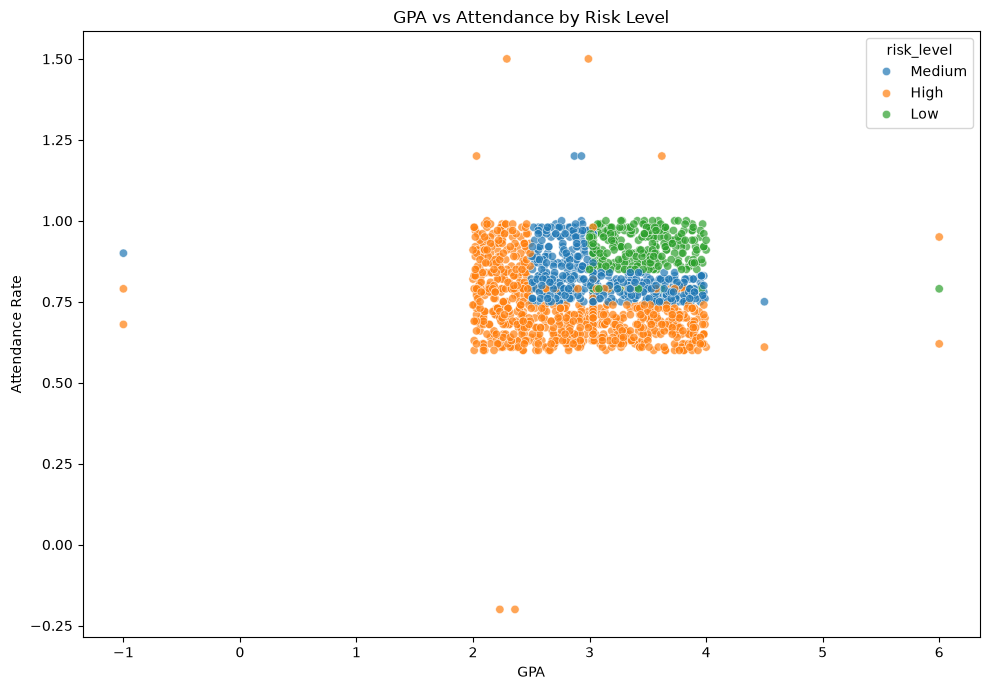

In [22]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="GPA",
    y="attendance_rate",
    hue="risk_level",
    alpha=0.7
)

plt.title("GPA vs Attendance by Risk Level")
plt.xlabel("GPA")
plt.ylabel("Attendance Rate")

plt.tight_layout()
plt.show()

In [23]:
df["GPA_band"] = pd.cut(
    df["GPA"],
    bins=[0, 2.5, 3.0, 4.1],
    labels=["Low GPA", "Medium GPA", "High GPA"]
)

df["attendance_band"] = pd.cut(
    df["attendance_rate"],
    bins=[0, 0.75, 0.85, 1.01],
    labels=["Low Attendance", "Medium Attendance", "High Attendance"]
)

risk_pattern = pd.crosstab(
    [df["GPA_band"], df["attendance_band"]],
    df["risk_level"],
    normalize="index"
)

print(risk_pattern.round(3).to_string())

risk_level                     High    Low  Medium
GPA_band   attendance_band                        
Low GPA    Low Attendance     0.992  0.000   0.008
           Medium Attendance  0.981  0.000   0.019
           High Attendance    0.991  0.000   0.009
Medium GPA Low Attendance     0.938  0.000   0.062
           Medium Attendance  0.064  0.011   0.926
           High Attendance    0.000  0.027   0.973
High GPA   Low Attendance     0.922  0.000   0.078
           Medium Attendance  0.084  0.126   0.791
           High Attendance    0.020  0.948   0.032


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df[["GPA", "attendance_rate"]]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.9695

              precision    recall  f1-score   support

        High       1.00      0.95      0.98       155
         Low       0.96      0.96      0.96        54
      Medium       0.92      1.00      0.96        86

    accuracy                           0.97       295
   macro avg       0.96      0.97      0.97       295
weighted avg       0.97      0.97      0.97       295



In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

online_behaviour_cols = [
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

X = df[online_behaviour_cols]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Behaviour-only Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

Behaviour-only Accuracy: 0.4

              precision    recall  f1-score   support

        High       0.53      0.55      0.54       155
         Low       0.17      0.15      0.16        54
      Medium       0.28      0.28      0.28        86

    accuracy                           0.40       295
   macro avg       0.33      0.33      0.33       295
weighted avg       0.39      0.40      0.40       295



In [26]:
combined_cols = [
    "GPA",
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

X = df[combined_cols]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

combined_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

combined_model.fit(X_train, y_train)

y_pred = combined_model.predict(X_test)

print("Combined Model Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

Combined Model Accuracy: 0.9661

              precision    recall  f1-score   support

        High       1.00      0.95      0.98       155
         Low       0.94      0.94      0.94        54
      Medium       0.92      1.00      0.96        86

    accuracy                           0.97       295
   macro avg       0.96      0.97      0.96       295
weighted avg       0.97      0.97      0.97       295



In [27]:
importance = pd.DataFrame({
    "feature": combined_cols,
    "importance": combined_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.round(4).to_string(index=False))

                     feature  importance
             attendance_rate      0.4775
                         GPA      0.3403
avg_session_duration_minutes      0.0401
       video_completion_rate      0.0390
  assignment_submission_rate      0.0363
       lms_logins_past_month      0.0354
   forum_participation_count      0.0314


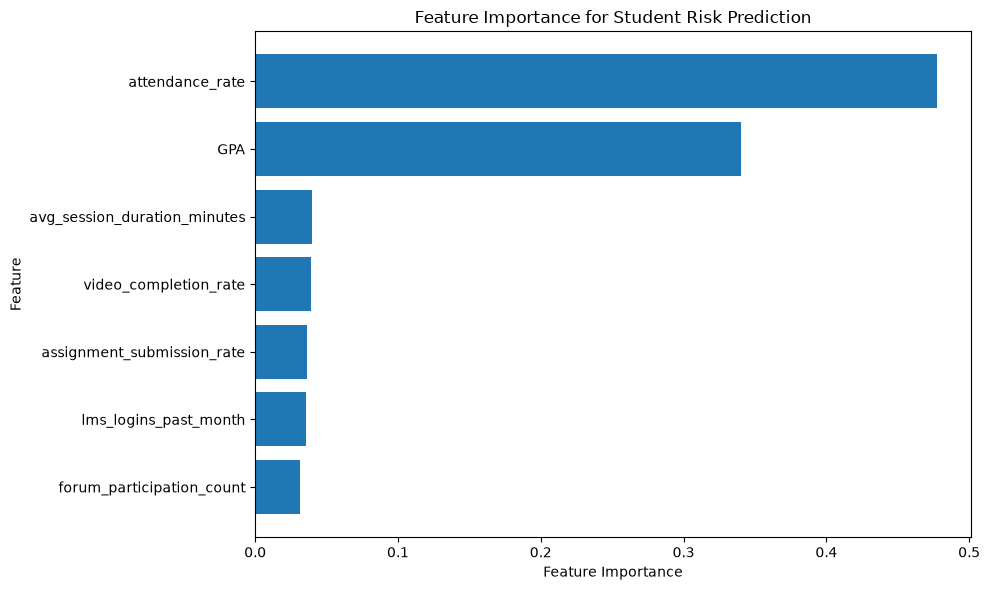

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Student Risk Prediction")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [29]:
pd.crosstab(
    pd.cut(
        df["GPA"],
        bins=[0, 2.5, 3.0, 3.5, 4.0],
        labels=["Low GPA", "Medium GPA", "High GPA", "Very High GPA"]
    ),
    df["risk_level"],
    normalize="index"
).round(3)

risk_level,High,Low,Medium
GPA,,,
Low GPA,0.989,0.000,0.011
Medium GPA,0.377,0.012,0.611
High GPA,0.372,0.344,0.285
Very High GPA,0.388,0.334,0.278


In [30]:
pd.crosstab(
    pd.cut(
        df["attendance_rate"],
        bins=[0.59, 0.75, 0.85, 1.0],
        labels=["Low Attendance", "Medium Attendance", "High Attendance"]
    ),
    df["risk_level"],
    normalize="index"
).round(3)

risk_level,High,Low,Medium
attendance_rate,,,
Low Attendance,0.941,0.000,0.059
Medium Attendance,0.295,0.073,0.632
High Attendance,0.240,0.506,0.253


In [31]:
analysis_cols = [
    "GPA",
    "avg_course_grade",
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

correlation = df[analysis_cols].corr()

print(correlation.round(3).to_string())

                                GPA  avg_course_grade  attendance_rate  lms_logins_past_month  avg_session_duration_minutes  assignment_submission_rate  forum_participation_count  video_completion_rate
GPA                           1.000             0.017           -0.018                  0.027                         0.026                      -0.003                      0.031                 -0.017
avg_course_grade              0.017             1.000            0.036                 -0.008                         0.009                       0.025                      0.004                  0.011
attendance_rate              -0.018             0.036            1.000                  0.002                         0.015                      -0.052                      0.009                 -0.016
lms_logins_past_month         0.027            -0.008            0.002                  1.000                         0.001                       0.008                     -0.031              

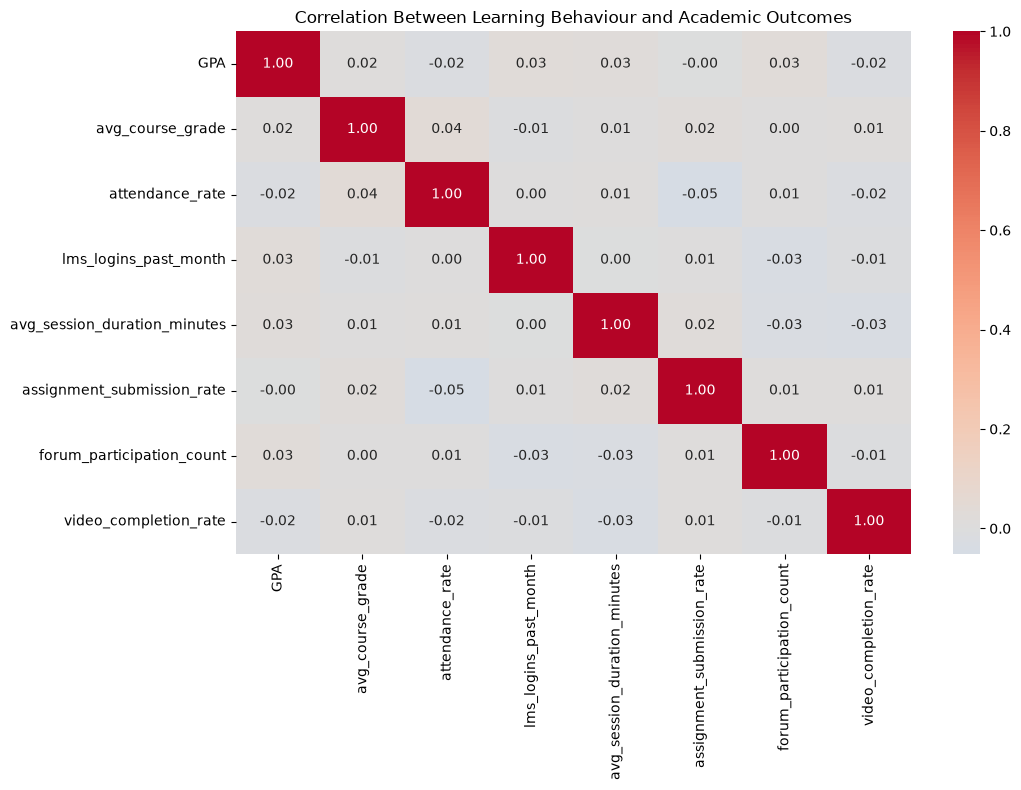

In [32]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Learning Behaviour and Academic Outcomes")
plt.tight_layout()
plt.show()

In [33]:
behaviour_cols = [
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

for col in behaviour_cols:
    df["behaviour_band"] = pd.qcut(
        df[col],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    print("\n", col)
    print(
        df.groupby("behaviour_band", observed=True)["GPA"]
        .agg(["count", "mean", "std"])
        .round(3)
    )


 lms_logins_past_month
                count   mean    std
behaviour_band                     
Low               512  3.007  0.572
Medium            485  2.984  0.645
High              478  3.038  0.604

 avg_session_duration_minutes
                count   mean    std
behaviour_band                     
Low               505  3.008  0.595
Medium            478  3.012  0.630
High              492  3.009  0.598

 assignment_submission_rate
                count   mean    std
behaviour_band                     
Low               498  3.009  0.563
Medium            488  3.034  0.638
High              489  2.985  0.620

 forum_participation_count
                count   mean    std
behaviour_band                     
Low               495  2.984  0.559
Medium            507  3.020  0.636
High              473  3.024  0.623

 video_completion_rate
                count   mean    std
behaviour_band                     
Low               496  3.006  0.622
Medium            498  3.015  0.606


In [34]:
for col in behaviour_cols:
    df["behaviour_band"] = pd.qcut(
        df[col],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    print("\n", col)
    print(
        df.groupby("behaviour_band", observed=True)["avg_course_grade"]
        .agg(["count", "mean", "std"])
        .round(3)
    )


 lms_logins_past_month
                count    mean     std
behaviour_band                       
Low               512  80.217  10.872
Medium            485  80.207  11.662
High              478  79.602  11.338

 avg_session_duration_minutes
                count    mean     std
behaviour_band                       
Low               505  79.882  11.153
Medium            478  80.212  11.480
High              492  79.957  11.244

 assignment_submission_rate
                count    mean     std
behaviour_band                       
Low               498  79.516  11.134
Medium            488  80.080  11.569
High              489  80.455  11.149

 forum_participation_count
                count    mean     std
behaviour_band                       
Low               495  80.124  11.506
Medium            507  79.536  11.271
High              473  80.412  11.065

 video_completion_rate
                count    mean     std
behaviour_band                       
Low               496  80.17

In [35]:
from scipy.stats import f_oneway

print("ANOVA: Behaviour Bands vs GPA")

for col in behaviour_cols:
    temp = df[[col, "GPA"]].copy()

    temp["behaviour_band"] = pd.qcut(
        temp[col],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    groups = [
        temp[temp["behaviour_band"] == "Low"]["GPA"],
        temp[temp["behaviour_band"] == "Medium"]["GPA"],
        temp[temp["behaviour_band"] == "High"]["GPA"]
    ]

    f_stat, p_value = f_oneway(*groups)

    print(f"{col}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print()

ANOVA: Behaviour Bands vs GPA
lms_logins_past_month
F-statistic: 0.9506
p-value: 0.386744

avg_session_duration_minutes
F-statistic: 0.0063
p-value: 0.993695

assignment_submission_rate
F-statistic: 0.8191
p-value: 0.441047

forum_participation_count
F-statistic: 0.6593
p-value: 0.517350

video_completion_rate
F-statistic: 0.0311
p-value: 0.969347



In [36]:
print("ANOVA: Behaviour Bands vs Average Course Grade")

for col in behaviour_cols:
    temp = df[[col, "avg_course_grade"]].copy()

    temp["behaviour_band"] = pd.qcut(
        temp[col],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    groups = [
        temp[temp["behaviour_band"] == "Low"]["avg_course_grade"],
        temp[temp["behaviour_band"] == "Medium"]["avg_course_grade"],
        temp[temp["behaviour_band"] == "High"]["avg_course_grade"]
    ]

    f_stat, p_value = f_oneway(*groups)

    print(f"{col}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print()

ANOVA: Behaviour Bands vs Average Course Grade
lms_logins_past_month
F-statistic: 0.4725
p-value: 0.623548

avg_session_duration_minutes
F-statistic: 0.1143
p-value: 0.891975

assignment_submission_rate
F-statistic: 0.8663
p-value: 0.420731

forum_participation_count
F-statistic: 0.7725
p-value: 0.462023

video_completion_rate
F-statistic: 0.6346
p-value: 0.530277



In [37]:
print(df["risk_level"].value_counts())
print()
print(df["risk_level"].value_counts(normalize=True).round(3))

risk_level
High      773
Medium    432
Low       270
Name: count, dtype: int64

risk_level
High      0.524
Medium    0.293
Low       0.183
Name: proportion, dtype: float64


In [38]:
print(
    df.groupby("risk_level")[["GPA", "attendance_rate", "avg_course_grade"]]
    .mean()
    .round(3)
)

              GPA  attendance_rate  avg_course_grade
risk_level                                          
High        2.803            0.732            79.763
Low         3.454            0.916            79.819
Medium      3.101            0.832            80.585


In [39]:
for risk in ["High", "Medium", "Low"]:
    print(f"\n{risk} Risk")
    print(
        df[df["risk_level"] == risk][
            ["GPA", "attendance_rate", "avg_course_grade"]
        ].describe().round(3)
    )


High Risk
           GPA  attendance_rate  avg_course_grade
count  773.000          773.000           773.000
mean     2.803            0.732            79.763
std      0.650            0.121            11.169
min     -1.000           -0.200            60.000
25%      2.270            0.650            70.300
50%      2.690            0.710            79.700
75%      3.290            0.790            89.300
max      6.000            1.500            99.900

Medium Risk
           GPA  attendance_rate  avg_course_grade
count  432.000          432.000           432.000
mean     3.101            0.832            80.585
std      0.477            0.072            11.071
min     -1.000            0.750            60.200
25%      2.760            0.780            71.550
50%      3.030            0.810            79.700
75%      3.462            0.870            90.300
max      4.500            1.200           100.000

Low Risk
           GPA  attendance_rate  avg_course_grade
count  270.000  

In [40]:
pd.crosstab(
    pd.cut(
        df["GPA"],
        bins=[1.9, 2.5, 3.0, 3.5, 4.0],
        labels=["Low GPA", "Medium GPA", "High GPA", "Very High GPA"]
    ),
    df["risk_level"],
    normalize="index"
).round(3)

risk_level,High,Low,Medium
GPA,,,
Low GPA,0.989,0.000,0.011
Medium GPA,0.377,0.012,0.611
High GPA,0.372,0.344,0.285
Very High GPA,0.388,0.334,0.278


In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

X = df[["GPA", "attendance_rate"]]

le = LabelEncoder()
y = le.fit_transform(df["risk_level"])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for depth in [1, 2, 3, 4, 5]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(
        f"Depth {depth}: "
        f"Mean Accuracy = {scores.mean():.4f}, "
        f"Std = {scores.std():.4f}"
    )

Depth 1: Mean Accuracy = 0.6447, Std = 0.0106
Depth 2: Mean Accuracy = 0.7925, Std = 0.0084
Depth 3: Mean Accuracy = 0.8780, Std = 0.0175
Depth 4: Mean Accuracy = 0.9586, Std = 0.0151
Depth 5: Mean Accuracy = 0.9586, Std = 0.0151


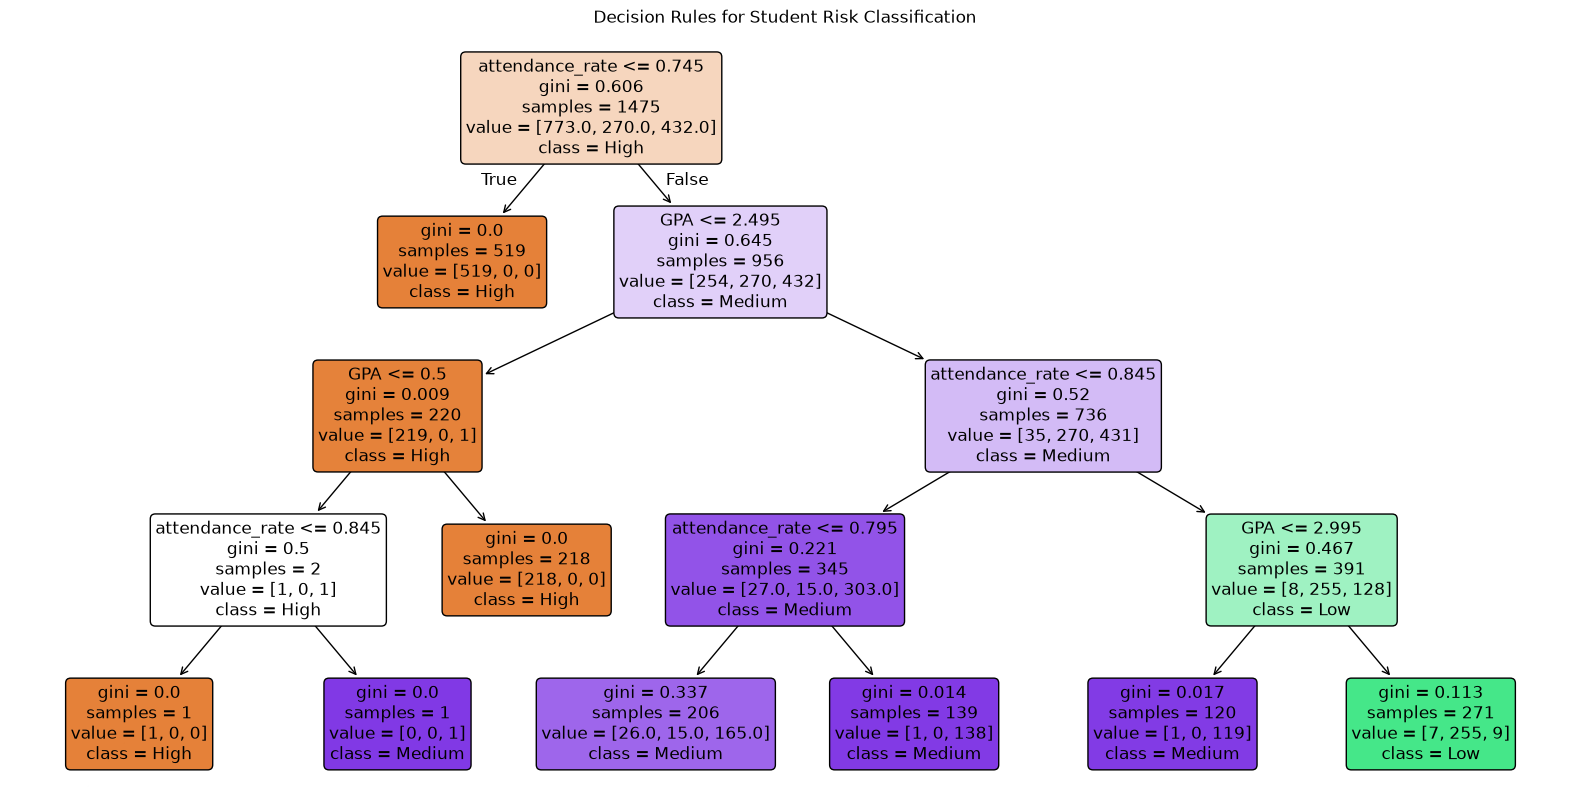

In [42]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

X = df[["GPA", "attendance_rate"]]
y = df["risk_level"]

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X, y)

plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=["GPA", "attendance_rate"],
    class_names=tree.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Rules for Student Risk Classification")
plt.show()

[[738   7  28]
 [  0 255  15]
 [  0   9 423]]


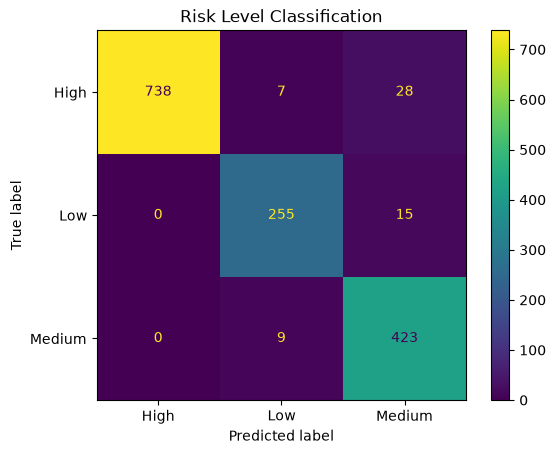

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = tree.predict(X)

print(confusion_matrix(y, y_pred, labels=tree.classes_))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred,
    labels=tree.classes_
)

plt.title("Risk Level Classification")
plt.show()

In [44]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

features = [
    "GPA",
    "attendance_rate",
    "avg_course_grade",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

le = LabelEncoder()
y_encoded = le.fit_transform(df["risk_level"])

mi = mutual_info_classif(
    df[features],
    y_encoded,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": features,
    "mutual_information": mi
}).sort_values(
    "mutual_information",
    ascending=False
)

print(mi_df.round(4).to_string(index=False))

                     feature  mutual_information
             attendance_rate              0.4610
                         GPA              0.2640
avg_session_duration_minutes              0.0236
   forum_participation_count              0.0086
       lms_logins_past_month              0.0070
  assignment_submission_rate              0.0014
            avg_course_grade              0.0000
       video_completion_rate              0.0000


In [45]:
behaviour_cols = [
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

academic_cols = [
    "GPA",
    "avg_course_grade"
]

corr = df[behaviour_cols + academic_cols].corr()

print(
    corr[academic_cols]
    .round(3)
)

                                GPA  avg_course_grade
attendance_rate              -0.018             0.036
lms_logins_past_month         0.027            -0.008
avg_session_duration_minutes  0.026             0.009
assignment_submission_rate   -0.003             0.025
forum_participation_count     0.031             0.004
video_completion_rate        -0.017             0.011
GPA                           1.000             0.017
avg_course_grade              0.017             1.000


In [46]:
from scipy.stats import pearsonr

for behaviour in behaviour_cols:
    for outcome in academic_cols:
        
        r, p = pearsonr(
            df[behaviour],
            df[outcome]
        )
        
        print(
            f"{behaviour} → {outcome}"
        )
        print(f"Correlation: {r:.4f}")
        print(f"p-value: {p:.6f}")
        print()

attendance_rate → GPA
Correlation: -0.0178
p-value: 0.494493

attendance_rate → avg_course_grade
Correlation: 0.0364
p-value: 0.162134

lms_logins_past_month → GPA
Correlation: 0.0274
p-value: 0.293658

lms_logins_past_month → avg_course_grade
Correlation: -0.0075
p-value: 0.773053

avg_session_duration_minutes → GPA
Correlation: 0.0258
p-value: 0.321959

avg_session_duration_minutes → avg_course_grade
Correlation: 0.0093
p-value: 0.720138

assignment_submission_rate → GPA
Correlation: -0.0032
p-value: 0.902184

assignment_submission_rate → avg_course_grade
Correlation: 0.0249
p-value: 0.339866

forum_participation_count → GPA
Correlation: 0.0306
p-value: 0.239709

forum_participation_count → avg_course_grade
Correlation: 0.0037
p-value: 0.888133

video_completion_rate → GPA
Correlation: -0.0173
p-value: 0.507424

video_completion_rate → avg_course_grade
Correlation: 0.0109
p-value: 0.676976



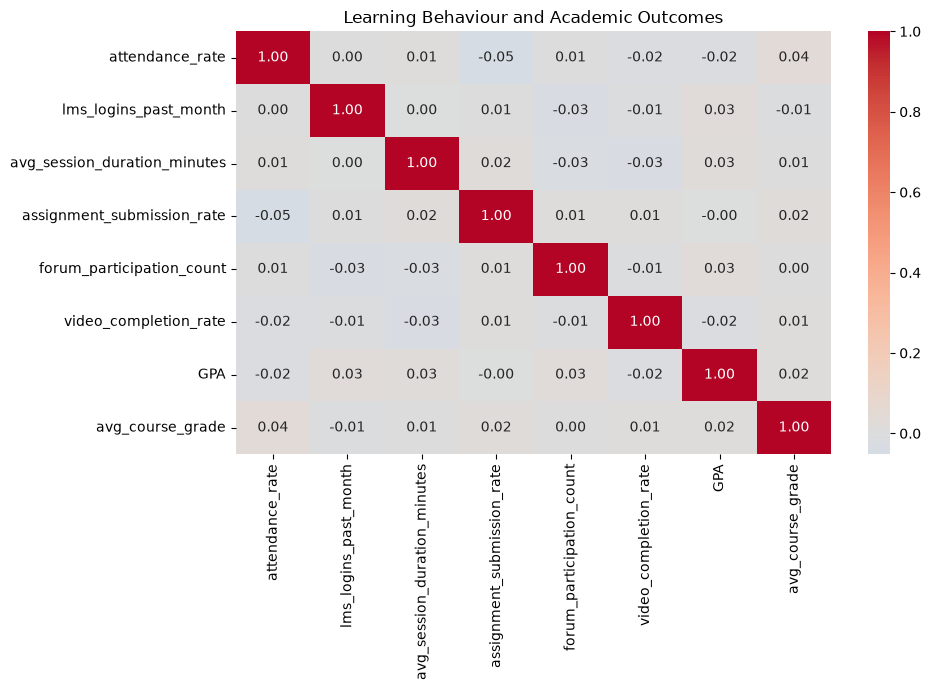

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[behaviour_cols + academic_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Learning Behaviour and Academic Outcomes")
plt.tight_layout()
plt.show()

In [48]:
behaviour_cols = [
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

academic_cols = [
    "GPA",
    "avg_course_grade"
]

corr = df[behaviour_cols + academic_cols].corr()

print(corr[academic_cols].round(3))

                                GPA  avg_course_grade
attendance_rate              -0.018             0.036
lms_logins_past_month         0.027            -0.008
avg_session_duration_minutes  0.026             0.009
assignment_submission_rate   -0.003             0.025
forum_participation_count     0.031             0.004
video_completion_rate        -0.017             0.011
GPA                           1.000             0.017
avg_course_grade              0.017             1.000


In [49]:
from scipy.stats import pearsonr

for behaviour in behaviour_cols:
    for outcome in academic_cols:
        r, p = pearsonr(df[behaviour], df[outcome])

        print(
            f"{behaviour} → {outcome} | "
            f"r = {r:.4f}, p = {p:.6f}"
        )

attendance_rate → GPA | r = -0.0178, p = 0.494493
attendance_rate → avg_course_grade | r = 0.0364, p = 0.162134
lms_logins_past_month → GPA | r = 0.0274, p = 0.293658
lms_logins_past_month → avg_course_grade | r = -0.0075, p = 0.773053
avg_session_duration_minutes → GPA | r = 0.0258, p = 0.321959
avg_session_duration_minutes → avg_course_grade | r = 0.0093, p = 0.720138
assignment_submission_rate → GPA | r = -0.0032, p = 0.902184
assignment_submission_rate → avg_course_grade | r = 0.0249, p = 0.339866
forum_participation_count → GPA | r = 0.0306, p = 0.239709
forum_participation_count → avg_course_grade | r = 0.0037, p = 0.888133
video_completion_rate → GPA | r = -0.0173, p = 0.507424
video_completion_rate → avg_course_grade | r = 0.0109, p = 0.676976


In [50]:
print(df.columns.tolist())

['student_id', 'age', 'gender', 'major', 'GPA', 'course_load', 'avg_course_grade', 'attendance_rate', 'enrollment_status', 'lms_logins_past_month', 'avg_session_duration_minutes', 'assignment_submission_rate', 'forum_participation_count', 'video_completion_rate', 'risk_level', 'GPA_band', 'attendance_band', 'behaviour_band']


In [51]:
print(df.head())

  student_id   age  gender             major   GPA  course_load  \
0      S1081  20.0    Male           Unknown  3.23            5   
1       S406  21.0    Male  Computer Science  2.97            4   
2      S1495  23.0  Female              Arts  2.39            3   
3       S240  25.0  Female          Business  3.91            4   
4       S611  22.0  Female       Engineering  3.89            3   

   avg_course_grade  attendance_rate enrollment_status  lms_logins_past_month  \
0              90.9             0.79         Graduated                   32.0   
1              63.9             0.97             Leave                   28.0   
2              93.1             0.67         Graduated                    7.0   
3              62.2             0.90         Graduated                   32.0   
4              71.0             0.82         Graduated                   30.0   

   avg_session_duration_minutes  assignment_submission_rate  \
0                          76.0                

In [52]:
print(df["risk_level"].head(20).tolist())

['Medium', 'Medium', 'High', 'Low', 'Medium', 'High', 'High', 'High', 'Low', 'High', 'High', 'Low', 'Medium', 'High', 'Low', 'High', 'Low', 'High', 'Low', 'Low']


In [53]:
print(df[["GPA", "attendance_rate", "risk_level"]].head(30).to_string(index=False))

 GPA  attendance_rate risk_level
3.23             0.79     Medium
2.97             0.97     Medium
2.39             0.67       High
3.91             0.90        Low
3.89             0.82     Medium
2.07             0.93       High
3.03             0.79       High
2.86             0.64       High
3.37             0.88        Low
2.18             0.72       High
2.31             0.68       High
3.39             0.97        Low
3.97             0.77     Medium
2.38             0.92       High
3.50             0.86        Low
3.44             0.62       High
3.95             0.95        Low
3.09             0.62       High
3.67             0.93        Low
3.22             0.93        Low
2.46             0.84       High
3.27             0.61       High
2.26             0.83       High
2.50             0.68       High
3.75             0.87        Low
3.91             0.92        Low
2.87             0.85     Medium
3.08             0.84     Medium
3.75             0.61       High
2.40      

In [54]:
print(
    df.groupby("risk_level")[["GPA", "attendance_rate"]]
      .agg(["min", "max", "mean"])
      .round(3)
)

            GPA             attendance_rate            
            min  max   mean             min  max   mean
risk_level                                             
High       -1.0  6.0  2.803           -0.20  1.5  0.732
Low         3.0  6.0  3.454            0.79  1.0  0.916
Medium     -1.0  4.5  3.101            0.75  1.2  0.832


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df[behaviour_cols]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

behaviour_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

behaviour_model.fit(X_train, y_train)

y_pred = behaviour_model.predict(X_test)

print("Behaviour-only Model")
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Behaviour-only Model
Accuracy: 0.7389830508474576

              precision    recall  f1-score   support

        High       1.00      0.68      0.81       155
         Low       0.52      0.96      0.68        54
      Medium       0.68      0.71      0.69        86

    accuracy                           0.74       295
   macro avg       0.73      0.78      0.73       295
weighted avg       0.82      0.74      0.75       295

Confusion Matrix:
[[105  23  27]
 [  0  52   2]
 [  0  25  61]]


In [56]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for depth in [1, 2, 3, 4, 5]:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(
        f"Depth {depth}: "
        f"Mean Accuracy = {scores.mean():.4f}, "
        f"Std = {scores.std():.4f}"
    )

Depth 1: Mean Accuracy = 0.6447, Std = 0.0106
Depth 2: Mean Accuracy = 0.7302, Std = 0.0225
Depth 3: Mean Accuracy = 0.7302, Std = 0.0225
Depth 4: Mean Accuracy = 0.7302, Std = 0.0359
Depth 5: Mean Accuracy = 0.7139, Std = 0.0210


In [57]:
combined_cols = behaviour_cols + [
    "GPA",
    "course_load",
    "avg_course_grade"
]

X_combined = df[combined_cols]

scores = cross_val_score(
    DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),
    X_combined,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Combined Model")
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

Combined Model
Mean Accuracy: 0.95864406779661
Std: 0.015068549675181635


In [58]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

feature_sets = {
    "Behaviour Only": behaviour_cols,

    "Behaviour + GPA": behaviour_cols + ["GPA"],

    "Behaviour + Attendance": behaviour_cols,

    "Behaviour + GPA + Course Load":
        behaviour_cols + ["GPA", "course_load"],

    "Behaviour + GPA + Course Grade":
        behaviour_cols + ["GPA", "avg_course_grade"],

    "All Features":
        combined_cols
}

for name, features in feature_sets.items():

    scores = cross_val_score(
        DecisionTreeClassifier(
            max_depth=2,
            random_state=42
        ),
        df[features],
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(
        f"{name}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Behaviour Only: 0.7302 ± 0.0225
Behaviour + GPA: 0.7925 ± 0.0084
Behaviour + Attendance: 0.7302 ± 0.0225
Behaviour + GPA + Course Load: 0.7925 ± 0.0084
Behaviour + GPA + Course Grade: 0.7925 ± 0.0084
All Features: 0.7925 ± 0.0084


In [59]:
behaviour_no_attendance = [
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

scores = cross_val_score(
    DecisionTreeClassifier(
        max_depth=2,
        random_state=42
    ),
    df[behaviour_no_attendance],
    y,
    cv=cv,
    scoring="accuracy"
)

print(
    "Behaviour without attendance:",
    scores.mean(),
    "±",
    scores.std()
)

Behaviour without attendance: 0.5152542372881357 ± 0.007730002882028059


In [60]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

model.fit(df[combined_cols], y)

importance_df = pd.DataFrame({
    "feature": combined_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance_df.round(4).to_string(index=False))

                     feature  importance
             attendance_rate      0.5439
                         GPA      0.4561
       lms_logins_past_month      0.0000
avg_session_duration_minutes      0.0000
  assignment_submission_rate      0.0000
   forum_participation_count      0.0000
       video_completion_rate      0.0000
                 course_load      0.0000
            avg_course_grade      0.0000


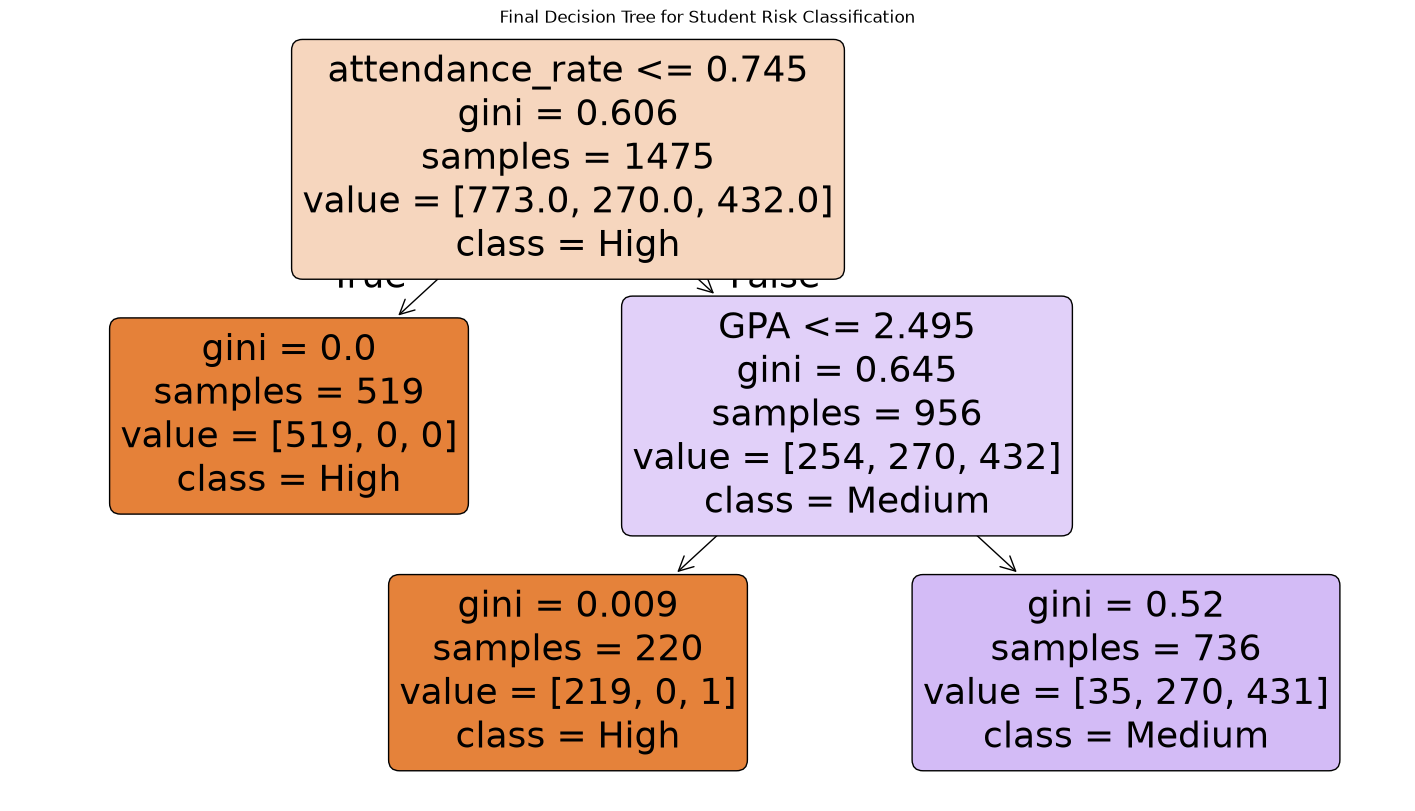

In [61]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=combined_cols,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.title("Final Decision Tree for Student Risk Classification")
plt.show()

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=2,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        df[combined_cols],
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(
        f"{name}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Decision Tree: 0.7925 ± 0.0084


/Users/shaikshaheerasara/Documents/capstone/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/shaikshaheerasara/Documents/capstone/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
 

Logistic Regression: 0.7146 ± 0.0033
Random Forest: 0.9546 ± 0.0195


In [63]:
print("Risk level counts:")
print(df["risk_level"].value_counts())

print("\nGPA by risk level:")
print(
    df.groupby("risk_level")["GPA"]
      .agg(["min", "max", "mean", "std"])
      .round(3)
)

print("\nAttendance by risk level:")
print(
    df.groupby("risk_level")["attendance_rate"]
      .agg(["min", "max", "mean", "std"])
      .round(3)
)

Risk level counts:
risk_level
High      773
Medium    432
Low       270
Name: count, dtype: int64

GPA by risk level:
            min  max   mean    std
risk_level                        
High       -1.0  6.0  2.803  0.650
Low         3.0  6.0  3.454  0.326
Medium     -1.0  4.5  3.101  0.477

Attendance by risk level:
             min  max   mean    std
risk_level                         
High       -0.20  1.5  0.732  0.121
Low         0.79  1.0  0.916  0.054
Medium      0.75  1.2  0.832  0.072


In [64]:
print(
    pd.crosstab(
        pd.cut(
            df["attendance_rate"],
            bins=[0, 0.745, 0.845, 1.0]
        ),
        df["risk_level"],
        normalize="index"
    ).round(3)
)

risk_level        High    Low  Medium
attendance_rate                      
(0.0, 0.745]     1.000  0.000   0.000
(0.745, 0.845]   0.287  0.034   0.679
(0.845, 1.0]     0.242  0.506   0.252


In [65]:
print(
    pd.crosstab(
        pd.cut(
            df["GPA"],
            bins=[0, 2.495, 2.995, 4.0]
        ),
        df["risk_level"],
        normalize="index"
    ).round(3)
)

risk_level       High    Low  Medium
GPA                                 
(0.0, 2.495]    1.000  0.000    0.00
(2.495, 2.995]  0.380  0.000    0.62
(2.995, 4.0]    0.378  0.341    0.28


In [66]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

rf.fit(df[combined_cols], y)

rf_importance = pd.DataFrame({
    "feature": combined_cols,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(rf_importance.round(4).to_string(index=False))

                     feature  importance
             attendance_rate      0.6041
                         GPA      0.3452
avg_session_duration_minutes      0.0127
            avg_course_grade      0.0111
  assignment_submission_rate      0.0074
       lms_logins_past_month      0.0067
       video_completion_rate      0.0065
   forum_participation_count      0.0045
                 course_load      0.0018


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

scores = cross_val_score(
    lr_model,
    df[combined_cols],
    y,
    cv=cv,
    scoring="accuracy"
)

print(
    f"Logistic Regression: "
    f"{scores.mean():.4f} ± {scores.std():.4f}"
)

Logistic Regression: 0.7492 ± 0.0107


In [68]:
behaviour_cols = [
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

academic_cols = [
    "GPA",
    "course_load",
    "avg_course_grade"
]

combined_cols = academic_cols + behaviour_cols

X_behaviour = df[behaviour_cols]
X_academic = df[academic_cols]
X_combined = df[combined_cols]

y = df["risk_level"]

In [69]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [70]:
feature_sets = {
    "Behaviour Only": X_behaviour,
    "Academic Only": X_academic,
    "Combined": X_combined
}

for name, X in feature_sets.items():

    model = DecisionTreeClassifier(
        max_depth=2,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(
        f"{name}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Behaviour Only: 0.7302 ± 0.0225
Academic Only: 0.5756 ± 0.0135
Combined: 0.7925 ± 0.0084


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    df[combined_cols],
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7932203389830509

              precision    recall  f1-score   support

        High       1.00      0.95      0.98       155
         Low       0.00      0.00      0.00        54
      Medium       0.59      1.00      0.74        86

    accuracy                           0.79       295
   macro avg       0.53      0.65      0.57       295
weighted avg       0.70      0.79      0.73       295


Confusion Matrix:
[[148   0   7]
 [  0   0  54]
 [  0   0  86]]


/Users/shaikshaheerasara/Documents/capstone/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shaikshaheerasara/Documents/capstone/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shaikshaheerasara/Documents/capstone/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [72]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

behaviour_cols = [
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

X = df[behaviour_cols]
y = df["risk_level"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

behaviour_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

scores = cross_val_score(
    behaviour_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print(f"Behaviour Model Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Behaviour Model Accuracy: 0.7302 ± 0.0225


In [73]:
academic_cols = [
    "GPA",
    "course_load",
    "avg_course_grade"
]

X_academic = df[academic_cols]
y = df["risk_level"]

academic_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

scores = cross_val_score(
    academic_model,
    X_academic,
    y,
    cv=cv,
    scoring="accuracy"
)

print(f"Academic Model Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Academic Model Accuracy: 0.5756 ± 0.0135


In [74]:
combined_cols = behaviour_cols + academic_cols

X_combined = df[combined_cols]
y = df["risk_level"]

combined_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

scores = cross_val_score(
    combined_model,
    X_combined,
    y,
    cv=cv,
    scoring="accuracy"
)

print(f"Combined Model Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Combined Model Accuracy: 0.7925 ± 0.0084


In [75]:
combined_model.fit(X_combined, y)

importance_df = pd.DataFrame({
    "Feature": combined_cols,
    "Importance": combined_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(importance_df.round(4).to_string(index=False))

                     Feature  Importance
             attendance_rate      0.5439
                         GPA      0.4561
       lms_logins_past_month      0.0000
avg_session_duration_minutes      0.0000
  assignment_submission_rate      0.0000
   forum_participation_count      0.0000
       video_completion_rate      0.0000
                 course_load      0.0000
            avg_course_grade      0.0000


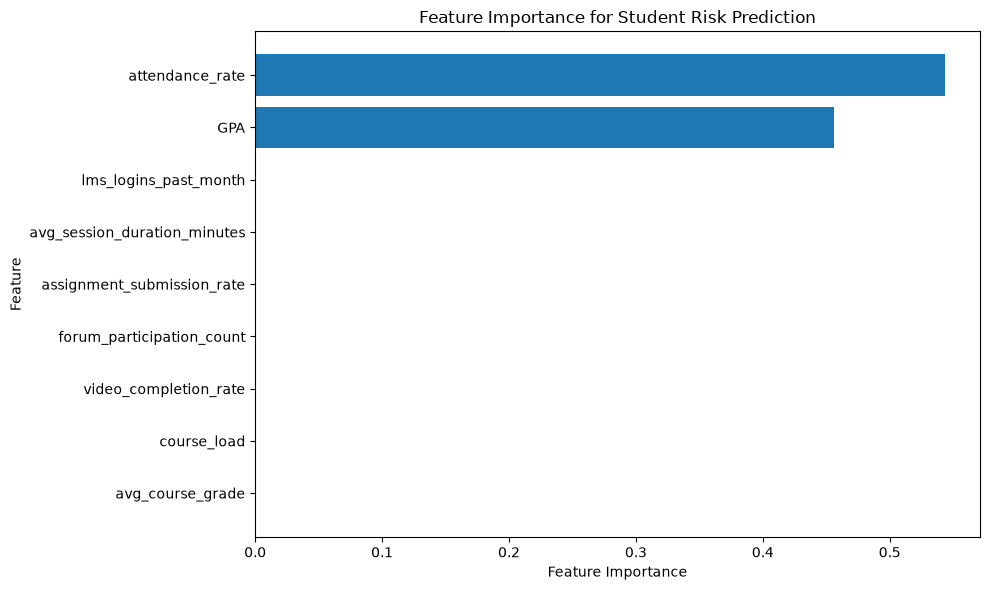

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Student Risk Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

combined_cols = [
    "GPA",
    "course_load",
    "avg_course_grade",
    "attendance_rate",
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

X = df[combined_cols]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

combined_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

combined_model.fit(X_train, y_train)

y_pred = combined_model.predict(X_test)

print("Combined Random Forest Model")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Combined Random Forest Model
Accuracy: 0.9695

              precision    recall  f1-score   support

        High       1.00      0.95      0.98       155
         Low       0.96      0.96      0.96        54
      Medium       0.92      1.00      0.96        86

    accuracy                           0.97       295
   macro avg       0.96      0.97      0.97       295
weighted avg       0.97      0.97      0.97       295

Confusion Matrix:
[[148   2   5]
 [  0  52   2]
 [  0   0  86]]


In [78]:
print("Unique student IDs:", df["student_id"].nunique())
print("Total rows:", len(df))
print("Duplicate student IDs:", df["student_id"].duplicated().sum())

print("\nRisk level by GPA and attendance:")
print(
    df.groupby("risk_level")[["GPA", "attendance_rate"]]
      .mean()
      .round(3)
)

print("\nRisk level counts:")
print(df["risk_level"].value_counts())

Unique student IDs: 1470
Total rows: 1475
Duplicate student IDs: 5

Risk level by GPA and attendance:
              GPA  attendance_rate
risk_level                        
High        2.803            0.732
Low         3.454            0.916
Medium      3.101            0.832

Risk level counts:
risk_level
High      773
Medium    432
Low       270
Name: count, dtype: int64


In [79]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_scores = cross_val_score(
    rf,
    df[combined_cols],
    y,
    cv=cv,
    scoring="accuracy"
)

print(
    f"Random Forest: "
    f"{rf_scores.mean():.4f} ± {rf_scores.std():.4f}"
)

Random Forest: 0.9553 ± 0.0171


In [80]:
rf.fit(df[combined_cols], y)

rf_importance = pd.DataFrame({
    "Feature": combined_cols,
    "Importance": rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(rf_importance.round(4).to_string(index=False))

                     Feature  Importance
             attendance_rate      0.5049
                         GPA      0.3422
            avg_course_grade      0.0297
avg_session_duration_minutes      0.0263
       video_completion_rate      0.0253
  assignment_submission_rate      0.0223
       lms_logins_past_month      0.0217
   forum_participation_count      0.0188
                 course_load      0.0088


Final Random Forest Model
Test Accuracy: 0.9695

              precision    recall  f1-score   support

        High       1.00      0.95      0.98       155
         Low       0.96      0.96      0.96        54
      Medium       0.92      1.00      0.96        86

    accuracy                           0.97       295
   macro avg       0.96      0.97      0.97       295
weighted avg       0.97      0.97      0.97       295

Confusion Matrix:
[[148   2   5]
 [  0  52   2]
 [  0   0  86]]


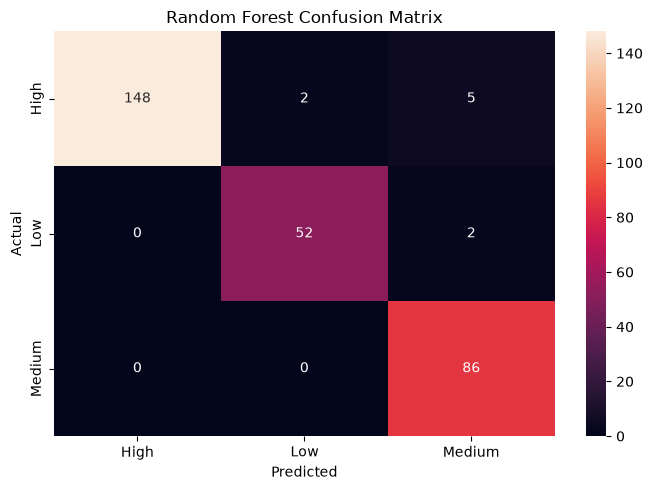

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = df[combined_cols]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

final_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

final_rf.fit(X_train, y_train)

y_pred = final_rf.predict(X_test)

print("Final Random Forest Model")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=final_rf.classes_,
    yticklabels=final_rf.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [82]:
import shap

explainer = shap.TreeExplainer(final_rf)

shap_values = explainer.shap_values(X_test)

print("SHAP analysis completed.")

SHAP analysis completed.


In [83]:
print("X_test shape:", X_test.shape)
print("SHAP values shape:", np.array(shap_values).shape)
print("Classes:", final_rf.classes_)

X_test shape: (295, 9)
SHAP values shape: (295, 9, 3)
Classes: ['High' 'Low' 'Medium']


SHAP Summary Plot - High


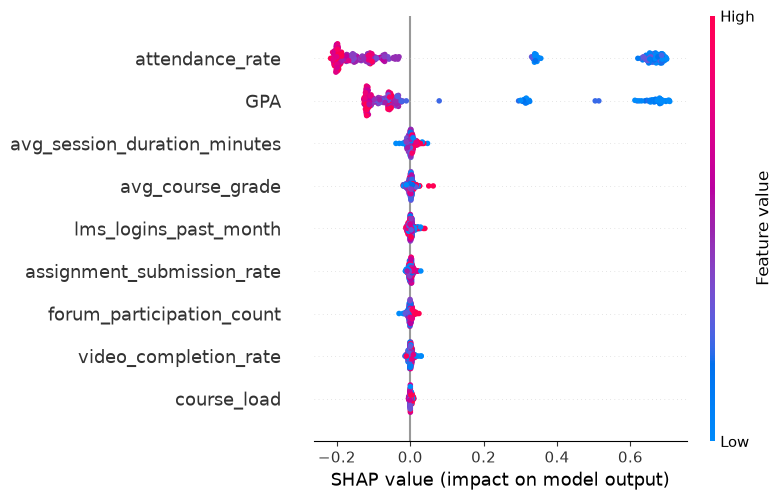

SHAP Summary Plot - Low


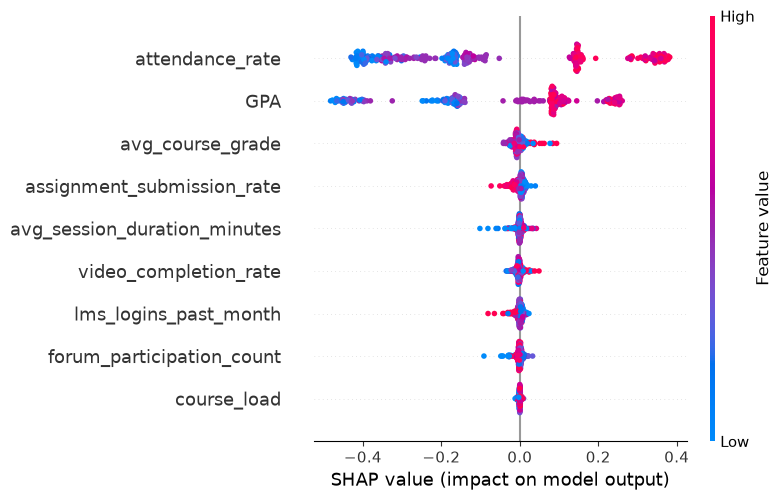

SHAP Summary Plot - Medium


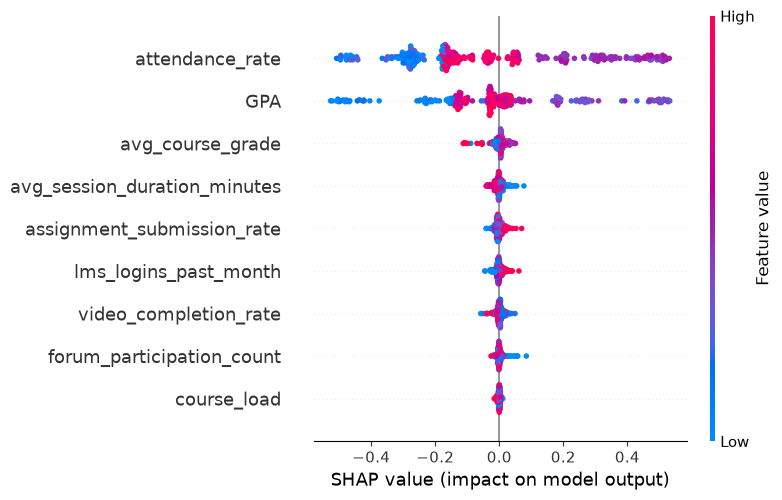

In [84]:
class_names = final_rf.classes_

for i, class_name in enumerate(class_names):
    print(f"SHAP Summary Plot - {class_name}")

    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        feature_names=combined_cols,
        show=True
    )

Student Index: 0
Predicted Risk Level: High


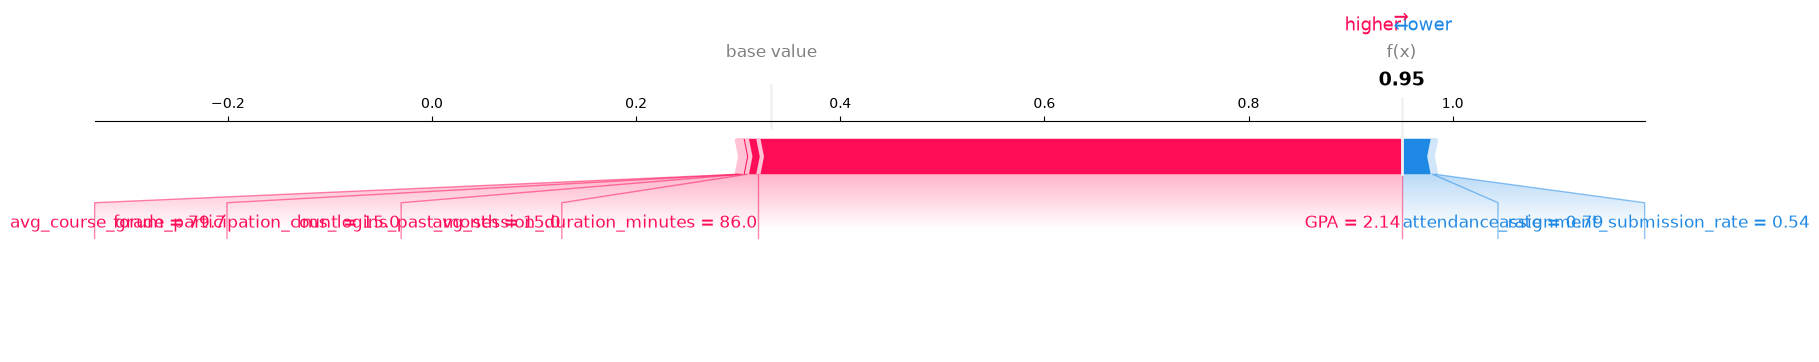

In [85]:
student_index = 0

student_features = X_test.iloc[[student_index]]
student_prediction = final_rf.predict(student_features)[0]

class_index = list(final_rf.classes_).index(student_prediction)

print("Student Index:", student_index)
print("Predicted Risk Level:", student_prediction)

shap.force_plot(
    explainer.expected_value[class_index],
    shap_values[student_index, :, class_index],
    student_features.iloc[0],
    matplotlib=True
)

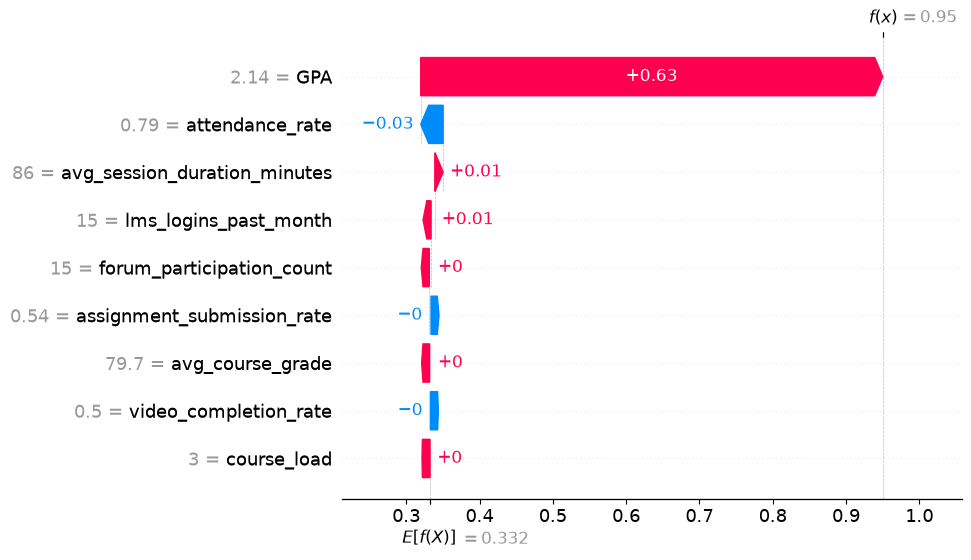

In [86]:
student_index = 0

class_index = list(final_rf.classes_).index(
    final_rf.predict(X_test.iloc[[student_index]])[0]
)

explanation = shap.Explanation(
    values=shap_values[student_index, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_test.iloc[student_index].values,
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation, max_display=9)

In [87]:
student_index = 0

student_prediction = final_rf.predict(X_test.iloc[[student_index]])[0]
class_index = list(final_rf.classes_).index(student_prediction)

student_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": X_test.iloc[student_index].values,
    "SHAP Contribution": shap_values[student_index, :, class_index]
})

student_explanation["Absolute Impact"] = (
    student_explanation["SHAP Contribution"].abs()
)

student_explanation = student_explanation.sort_values(
    "Absolute Impact",
    ascending=False
)

print("Predicted Risk:", student_prediction)
print()
print(student_explanation.round(4).to_string(index=False))

Predicted Risk: High

                     Feature  Value  SHAP Contribution  Absolute Impact
                         GPA   2.14             0.6302           0.6302
             attendance_rate   0.79            -0.0306           0.0306
avg_session_duration_minutes  86.00             0.0113           0.0113
       lms_logins_past_month  15.00             0.0052           0.0052
   forum_participation_count  15.00             0.0024           0.0024
  assignment_submission_rate   0.54            -0.0024           0.0024
            avg_course_grade  79.70             0.0019           0.0019
       video_completion_rate   0.50            -0.0010           0.0010
                 course_load   3.00             0.0005           0.0005


In [89]:
print("Risk level by GPA and attendance:")

print(
    df.groupby("risk_level")[["GPA", "attendance_rate"]]
      .mean()
      .round(3)
)

print("\nGPA ranges by risk level:")

print(
    df.groupby("risk_level")["GPA"]
      .agg(["min", "mean", "max"])
      .round(3)
)

print("\nAttendance ranges by risk level:")

print(
    df.groupby("risk_level")["attendance_rate"]
      .agg(["min", "mean", "max"])
      .round(3)
)

Risk level by GPA and attendance:
              GPA  attendance_rate
risk_level                        
High        2.803            0.732
Low         3.454            0.916
Medium      3.101            0.832

GPA ranges by risk level:
            min   mean  max
risk_level                 
High       -1.0  2.803  6.0
Low         3.0  3.454  6.0
Medium     -1.0  3.101  4.5

Attendance ranges by risk level:
             min   mean  max
risk_level                  
High       -0.20  0.732  1.5
Low         0.79  0.916  1.0
Medium      0.75  0.832  1.2


In [90]:
behaviour_no_academic = [
    "lms_logins_past_month",
    "avg_session_duration_minutes",
    "assignment_submission_rate",
    "forum_participation_count",
    "video_completion_rate"
]

X = df[behaviour_no_academic]
y = df["risk_level"]

scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print(
    f"Random Forest without GPA and attendance: "
    f"{scores.mean():.4f} ± {scores.std():.4f}"
)


Random Forest without GPA and attendance: 0.4041 ± 0.0182


In [91]:
feature_sets = {
    "Behaviour Only": behaviour_no_academic,

    "Behaviour + GPA": behaviour_no_academic + ["GPA"],

    "Behaviour + Attendance":
        behaviour_no_academic + ["attendance_rate"],

    "Behaviour + GPA + Attendance":
        behaviour_no_academic + ["GPA", "attendance_rate"]
}

for name, features in feature_sets.items():

    scores = cross_val_score(
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ),
        df[features],
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(
        f"{name}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Behaviour Only: 0.4041 ± 0.0182
Behaviour + GPA: 0.5715 ± 0.0200
Behaviour + Attendance: 0.7173 ± 0.0164
Behaviour + GPA + Attendance: 0.9566 ± 0.0157


In [92]:
print("Invalid GPA values:")
print(df[df["GPA"] < 0][["student_id", "GPA", "risk_level"]])

print("\nGPA values above 4:")
print(df[df["GPA"] > 4][["student_id", "GPA", "risk_level"]])

print("\nInvalid attendance values:")
print(
    df[
        (df["attendance_rate"] < 0) |
        (df["attendance_rate"] > 1)
    ][["student_id", "attendance_rate", "risk_level"]]
)

Invalid GPA values:
    student_id  GPA risk_level
128      S1407 -1.0       High
698       S719 -1.0     Medium
813       S449 -1.0       High

GPA values above 4:
     student_id  GPA risk_level
490        S781  4.5     Medium
817       S1233  6.0       High
1053       S522  4.5       High
1094       S823  6.0        Low
1100       S005  6.0       High

Invalid attendance values:
     student_id  attendance_rate risk_level
195       S260              -0.2       High
209        S591              1.5       High
218        S880              1.5       High
227        S262              1.2       High
275       S1525             -0.2       High
916        S233              1.2       High
1249       S403              1.2     Medium
1464       S331              1.2     Medium


In [93]:
print("Negative GPA:", (df["GPA"] < 0).sum())
print("GPA > 4:", (df["GPA"] > 4).sum())

print(
    "Attendance < 0:",
    (df["attendance_rate"] < 0).sum()
)

print(
    "Attendance > 1:",
    (df["attendance_rate"] > 1).sum()
)

Negative GPA: 3
GPA > 4: 5
Attendance < 0: 2
Attendance > 1: 6
